EN3160 Assignment 01

Intensity Transformations and Spatial Filtering

Name: Hasindu Gunasekara  
Index Number: 230208C

GitHub: 

Objective

This assignment investigates intensity transformations and spatial filtering
techniques using Python, NumPy, Matplotlib, and OpenCV.

The implemented techniques include piecewise intensity transformations,
gamma correction, histogram equalization, Sobel filtering, interpolation,
GrabCut segmentation, and bilateral filtering.

In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

from skimage import color

print("OpenCV version:", cv.__version__)
print("NumPy version:", np.__version__)

OpenCV version: 5.0.0
NumPy version: 2.2.3


Question 1 — Piecewise Intensity Transformation

Objective

Implement a piecewise-linear intensity transformation using the specified
breakpoints and investigate how different breakpoint choices affect the
appearance of the image.

Theory

An intensity transformation changes the intensity of each pixel according to
a transformation function:

\[
g(x) = T(f(x))
\]

The output intensity depends only on the original intensity of the
corresponding pixel.

In [7]:
im1 = cv.imread("images/emma.png",
                cv.IMREAD_GRAYSCALE)

assert im1 is not None, "Q1 image could not be loaded"

print("Image shape:", im1.shape)
print("Data type:", im1.dtype)

Image shape: (407, 362)
Data type: uint8


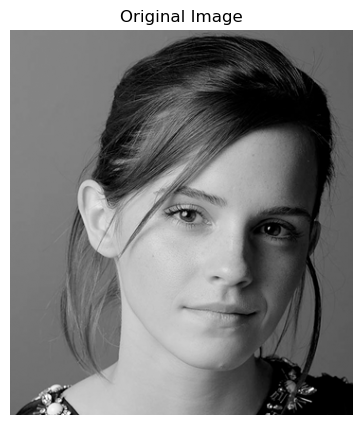

In [8]:
plt.figure(figsize=(6, 5))
plt.imshow(im1, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [9]:
breakpoints = np.array([
    [0,   0],
    [50,  50],
    [100, 150],
    [150, 255],
    [255, 255]
])

print(breakpoints)

[[  0   0]
 [ 50  50]
 [100 150]
 [150 255]
 [255 255]]


In [10]:
def intensity_transform(im, breakpoints):

    # Create an empty lookup table for 256 intensity values
    transform = np.zeros(256, dtype=np.uint8)

    # Process each interval between consecutive breakpoints
    for i in range(len(breakpoints) - 1):

        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]

        # Generate input intensities in this interval
        x_values = np.arange(x1, x2 + 1)

        # Linear interpolation
        y_values = y1 + (x_values - x1) * (y2 - y1) / (x2 - x1)

        transform[x_values] = np.round(y_values).astype(np.uint8)

    # Apply the lookup table to the image
    output = transform[im]

    return output, transform

In [11]:
im1_transformed, transform1 = intensity_transform(
    im1,
    breakpoints
)

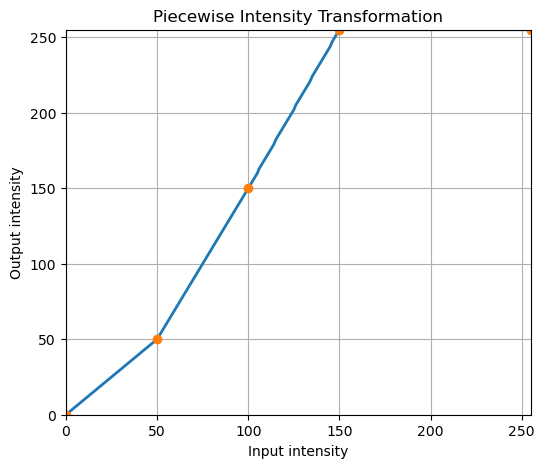

In [12]:
plt.figure(figsize=(6, 5))

plt.plot(
    np.arange(256),
    transform1,
    linewidth=2
)

plt.plot(
    breakpoints[:, 0],
    breakpoints[:, 1],
    "o"
)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Piecewise Intensity Transformation")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)

plt.show()

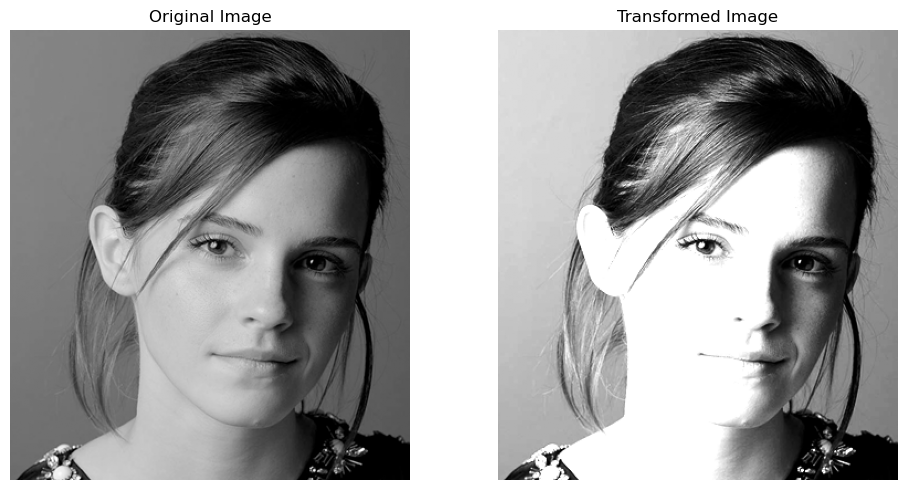

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(im1, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(im1_transformed, cmap="gray", vmin=0, vmax=255)
ax[1].set_title("Transformed Image")
ax[1].axis("off")

plt.tight_layout()
plt.show()

In [14]:
breakpoints_test = np.array([
    [0,   0],
    [40,  20],
    [100, 180],
    [160, 255],
    [255, 255]
])

test_image, test_transform = intensity_transform(
    im1,
    breakpoints_test
)

Discussion

The piecewise intensity transformation maps each input intensity to a new
output intensity using the selected breakpoints. The intensity ranges of
greater interest were expanded, while other ranges were compressed.

Different breakpoint combinations were tested and the final set was selected
based on the visual contrast and visibility of details in the transformed
image.